In [ ]:
!pip -q install catboost tldextract

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 4.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from catboost import CatBoostClassifier, Pool
import shap
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Đồ án tốt nghiệp/Datasets/PhiUSIIL_Phishing_URL_Dataset.csv")
# df = df.drop(columns=['Unnamed: 0'])


In [ ]:
df.drop_duplicates()

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.000000,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.000000,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.000000,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.000000,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.000000,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235790,https://www.skincareliving.com,29,www.skincareliving.com,22,0,com,100.000000,1.000000,0.522907,0.058739,...,1,0,1,51,7,21,187,2,191,1
235791,https://www.winchester.gov.uk,28,www.winchester.gov.uk,21,0,uk,100.000000,0.785714,0.028555,0.053834,...,1,0,0,50,1,7,88,0,31,1
235792,https://www.nononsensedesign.be,30,www.nononsensedesign.be,23,0,be,100.000000,1.000000,0.003319,0.063093,...,0,0,1,27,10,30,58,2,67,1
235793,https://patient-cell-40f5.updatedlogmylogin.wo...,55,patient-cell-40f5.updatedlogmylogin.workers.dev,47,0,dev,28.157537,0.465116,0.000961,0.050211,...,0,0,0,0,0,3,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  object 
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  object 
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  object 
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation              235795 non-null  int64  
 13  NoOfObfuscated

In [ ]:
df.head()

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


In [ ]:
df["Label"] = df["Label"].str.strip().str.lower()
df["Label_num"] = df["Label"].map({
    "legitimate": 0,
    "phishing": 1
})

AttributeError: Can only use .str accessor with string values!

In [ ]:
drop_cols = [
    # "Label",
    # "Label_num",
    "URL",
    "Domain",
    "TLD",
    "label",
    "Title",
    "URLSimilarityIndex",
    "URLLength",
    "DomainTitleMatchScore",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "CharContinuationRate",
    "TLDLegitimateProb",
    "URLCharProb",
]
# X = df[selected_features]
X = df.drop(columns=drop_cols)
y = df["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (212215, 41)
Test shape: (23580, 41)


In [ ]:
cat_features = [col for col in X_train.columns if X_train[col].dtype == "object"]
print("Categorical features:", cat_features)

Categorical features: []


In [ ]:
train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

In [ ]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",           # đổi sang AUC — tốt hơn Accuracy cho imbalanced data
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100,

    # Thêm:
    l2_leaf_reg=3,               # L2 regularization, default=3, tăng lên nếu overfit
    bagging_temperature=1,       # randomness khi sampling, giúp generalize tốt hơn
    border_count=128,            # số bin để discretize features, 336k rows nên dùng cao
    thread_count=-1,             # dùng toàn bộ CPU cores
)

In [ ]:
model.fit(
    train_pool,
    eval_set=test_pool,
    plot=True               # đổi thành True nếu dùng Jupyter
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.9991416	best: 0.9991416 (0)	total: 70.1ms	remaining: 35s
100:	test: 1.0000000	best: 1.0000000 (98)	total: 6.85s	remaining: 27.1s
200:	test: 1.0000000	best: 1.0000000 (200)	total: 14.9s	remaining: 22.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1
bestIteration = 200

Shrink model to first 201 iterations.


CatBoostClassifier(bagging_temperature=1, border_count=128, depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=500, l2_leaf_reg=3, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [ ]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred,
    target_names=["legitimate", "phishing"]
))


Accuracy: 0.9999575911789652

Classification Report:
               precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00     10095
    phishing       1.00      1.00      1.00     13485

    accuracy                           1.00     23580
   macro avg       1.00      1.00      1.00     23580
weighted avg       1.00      1.00      1.00     23580



In [ ]:
model.save_model("/content/drive/MyDrive/Đồ án tốt nghiệp/catboost_model.cbm")


Top 20 Feature Importance:
LineOfCode                    1.529024e+01
IsHTTPS                       1.416714e+01
NoOfOtherSpecialCharsInURL    1.294940e+01
NoOfSelfRef                   8.900558e+00
LetterRatioInURL              8.289937e+00
LargestLineLength             7.416278e+00
NoOfSubDomain                 5.640576e+00
NoOfDegitsInURL               5.552263e+00
NoOfImage                     2.825359e+00
NoOfExternalRef               2.628949e+00
HasDescription                2.150376e+00
DegitRatioInURL               2.099779e+00
NoOfLettersInURL              1.982201e+00
URLTitleMatchScore            1.832801e+00
HasSocialNet                  1.457453e+00
NoOfJS                        1.411430e+00
SpacialCharRatioInURL         1.278561e+00
NoOfCSS                       1.084666e+00
DomainLength                  1.046609e+00
HasCopyrightInfo              1.007046e+00
TLDLength                     3.408891e-01
HasTitle                      1.897023e-01
Crypto                    

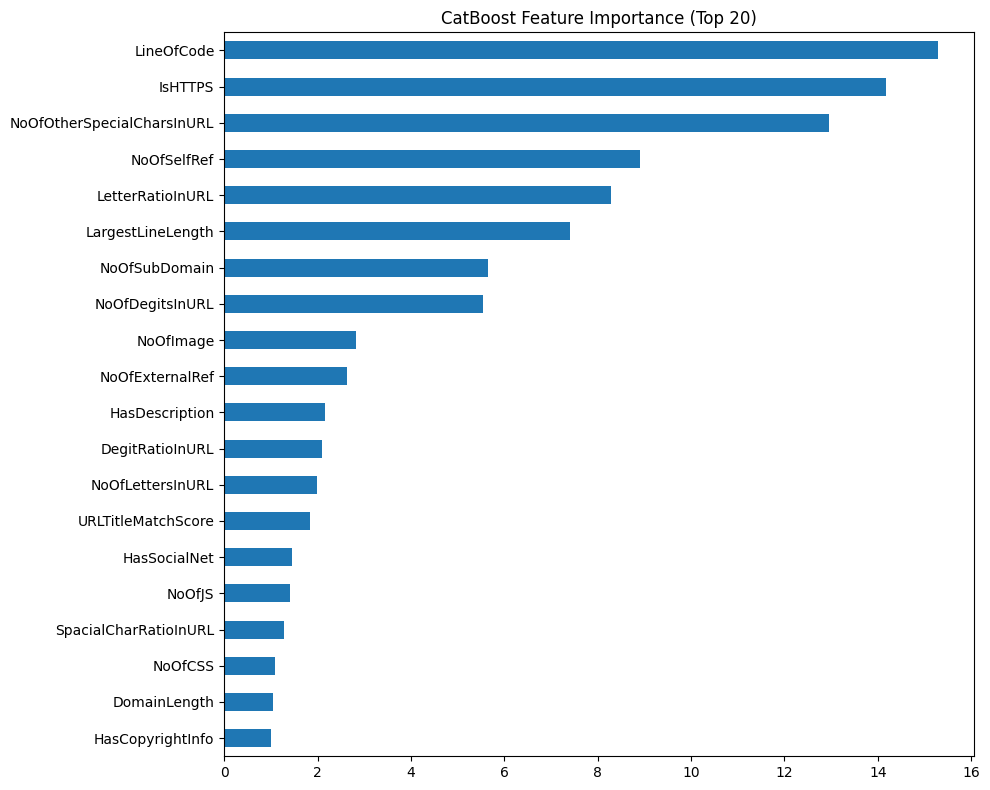

In [ ]:
feat_imp = pd.Series(
    model.get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 20 Feature Importance:")
print(feat_imp.head(58))

plt.figure(figsize=(10, 8))
feat_imp.head(20).plot(kind="barh")
plt.title("CatBoost Feature Importance (Top 20)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

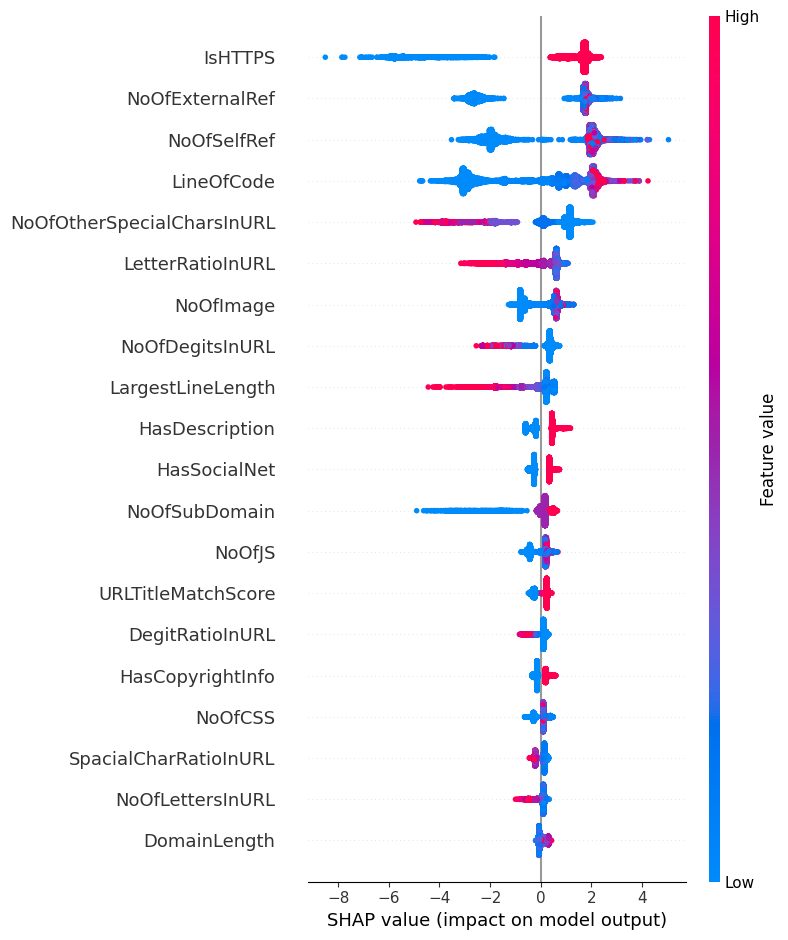

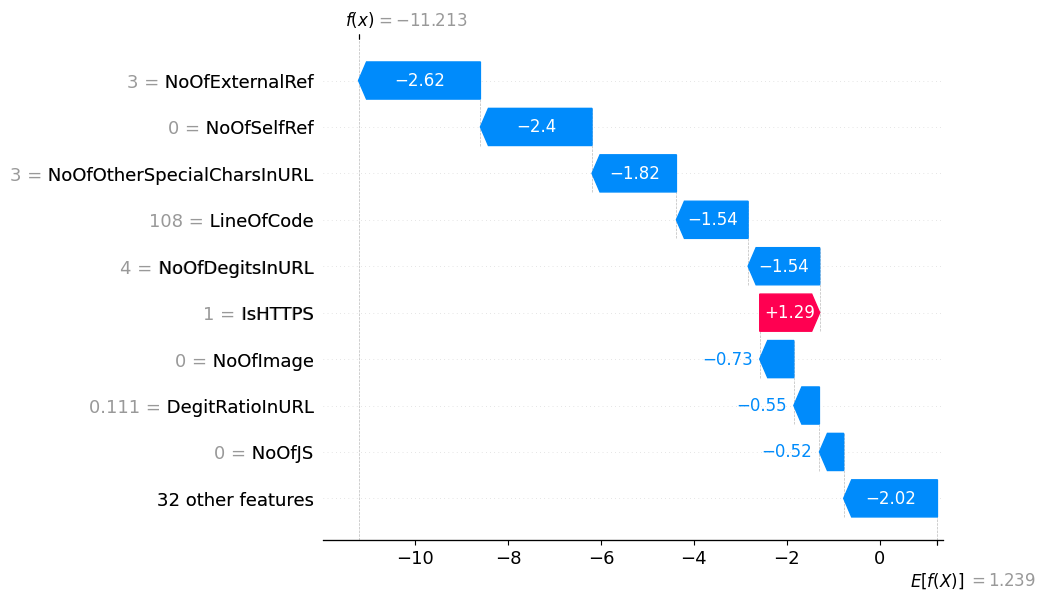

In [ ]:
explainer = shap.TreeExplainer(model)

X_sample = X_train.sample(10000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Summary plot
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150)
plt.show()

# Waterfall plot cho 1 mẫu đơn lẻ (tuỳ chọn)
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_sample.iloc[0],
        feature_names=X_sample.columns.tolist()
    )
)

In [ ]:
import pandas as pd
import numpy as np

# Tính giá trị trung bình tuyệt đối SHAP cho mỗi feature
shap_importance = np.abs(shap_values).mean(axis=0)

# Đưa vào Series để dễ sắp xếp
shap_importance_series = pd.Series(shap_importance, index=X_sample.columns)

# Sắp xếp giảm dần
shap_importance_sorted = shap_importance_series.sort_values(ascending=False)

# In top 20 feature quan trọng nhất theo SHAP
print(shap_importance_sorted.head(60))


IsHTTPS                       2.290937
NoOfExternalRef               2.151641
NoOfSelfRef                   2.044613
LineOfCode                    1.928999
NoOfOtherSpecialCharsInURL    1.366052
LetterRatioInURL              0.731864
NoOfImage                     0.620040
NoOfDegitsInURL               0.579840
LargestLineLength             0.463377
HasDescription                0.394801
HasSocialNet                  0.324080
NoOfSubDomain                 0.309805
NoOfJS                        0.299913
URLTitleMatchScore            0.268217
DegitRatioInURL               0.211111
HasCopyrightInfo              0.204147
NoOfCSS                       0.195167
SpacialCharRatioInURL         0.175139
NoOfLettersInURL              0.144569
DomainLength                  0.105931
HasTitle                      0.024022
TLDLength                     0.017373
Bank                          0.012809
Crypto                        0.010370
NoOfiFrame                    0.010319
Robots                   

In [ ]:
selected_features = [
    "IsHTTPS",
    "NoOfExternalRef",
    "NoOfSelfRef",
    "LineOfCode",
    "LetterRatioInURL",
    "NoOfImage",
    "LargestLineLength",
    "HasDescription",
    "HasSocialNet",
    "NoOfSubDomain",
    "NoOfJS",
    "URLTitleMatchScore",
    "DegitRatioInURL",
    "SpacialCharRatioInURL",
    "DomainLength"
]

In [ ]:
df_clean = pd.read_csv("/content/drive/MyDrive/Đồ án tốt nghiệp/clean_dataset_url.csv")
df_clean = df_clean.drop(columns=['Unnamed: 0'])

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257962 entries, 0 to 257961
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   label                  257962 non-null  int64  
 1   IsHTTPS                257962 non-null  int64  
 2   NoOfExternalRef        257962 non-null  int64  
 3   NoOfSelfRef            257962 non-null  int64  
 4   LineOfCode             257962 non-null  int64  
 5   LetterRatioInURL       257962 non-null  float64
 6   NoOfImage              257962 non-null  int64  
 7   LargestLineLength      257962 non-null  int64  
 8   HasDescription         257962 non-null  int64  
 9   HasSocialNet           257962 non-null  int64  
 10  NoOfSubDomain          257962 non-null  int64  
 11  NoOfJS                 257962 non-null  int64  
 12  URLTitleMatchScore     257962 non-null  float64
 13  DegitRatioInURL        257962 non-null  float64
 14  SpacialCharRatioInURL  257962 non-nu

In [ ]:
df_clean["label"].value_counts()

,count
label,
1,157017
0,100945


In [ ]:
X = df_clean.drop(columns=["label"])
y = df_clean["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (232165, 15)
Test shape: (25797, 15)


In [ ]:
cat_features = [col for col in X_train.columns if X_train[col].dtype == "object"]
print("Categorical features:", cat_features)

Categorical features: []


In [ ]:
train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

In [ ]:
counter = Counter(y_train)
print(counter)

# weight = total / (num_classes * count_class)
total = len(y_train)
class_weights = {
    0: total / (2 * counter[0]),
    1: total / (2 * counter[1]),
}

model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.01,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",  # đổi luôn
    class_weights=class_weights,
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100,
)

Counter({1: 141315, 0: 90850})


In [ ]:
model.fit(
    train_pool,
    eval_set=test_pool,
    plot=True               # đổi thành True nếu dùng Jupyter
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.9966006	best: 0.9966006 (0)	total: 169ms	remaining: 5m 38s
100:	test: 0.9996315	best: 0.9996315 (100)	total: 9.15s	remaining: 2m 52s
200:	test: 0.9998149	best: 0.9998149 (200)	total: 16.4s	remaining: 2m 26s
300:	test: 0.9999112	best: 0.9999112 (300)	total: 26.1s	remaining: 2m 27s
400:	test: 0.9999484	best: 0.9999484 (400)	total: 35s	remaining: 2m 19s
500:	test: 0.9999651	best: 0.9999651 (500)	total: 41.3s	remaining: 2m 3s
600:	test: 0.9999755	best: 0.9999755 (599)	total: 50.2s	remaining: 1m 56s
700:	test: 0.9999808	best: 0.9999808 (700)	total: 56.5s	remaining: 1m 44s
800:	test: 0.9999847	best: 0.9999847 (800)	total: 1m 5s	remaining: 1m 38s
900:	test: 0.9999875	best: 0.9999875 (899)	total: 1m 13s	remaining: 1m 29s
1000:	test: 0.9999897	best: 0.9999897 (999)	total: 1m 24s	remaining: 1m 24s
1100:	test: 0.9999911	best: 0.9999911 (1100)	total: 1m 33s	remaining: 1m 16s
1200:	test: 0.9999921	best: 0.9999921 (1200)	total: 1m 41s	remaining: 1m 7s
1300:	test: 0.9999931	best: 0.9999931

CatBoostClassifier(class_weights={0: 1.2777380297193175, 1: 0.8214449987616318}, depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=2000, learning_rate=0.01, loss_function='Logloss', random_seed=42, verbose=100)

In [ ]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred,
    target_names=["legitimate", "phishing"]
))


Accuracy: 0.9994573012365779

Classification Report:
               precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00     10095
    phishing       1.00      1.00      1.00     15702

    accuracy                           1.00     25797
   macro avg       1.00      1.00      1.00     25797
weighted avg       1.00      1.00      1.00     25797



In [ ]:
model.save_model("/content/drive/MyDrive/Đồ án tốt nghiệp/catboost_model_reduced.cbm")

In [ ]:
import re
import math
import requests
from urllib.parse import urlparse, urljoin
from bs4 import BeautifulSoup

# ======================
# Config
# ======================
TIMEOUT = 8
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/122.0.0.0 Safari/537.36"
    )
}


# ======================
# Helper: fetch page
# ======================
def fetch_page(url):
    """
    Trả về (response, soup).
    Nếu lỗi trả về (None, None).
    """
    try:
        resp = requests.get(
            url,
            headers=HEADERS,
            timeout=TIMEOUT,
            allow_redirects=True,
            verify=False,          # bỏ SSL verify để tránh timeout trên cert lỗi
        )
        soup = BeautifulSoup(resp.text, "html.parser")
        return resp, soup
    except Exception:
        return None, None


# ======================
# Shannon entropy (dùng lại từ layer1)
# ======================
def shannon_entropy(s):
    if not s:
        return 0
    prob = [s.count(c) / len(s) for c in set(s)]
    return -sum(p * math.log2(p) for p in prob)


# ======================
# Extract features (HTML-level)
# ======================
def extract_features_html_style(url):
    try:
        url = str(url)
        parsed = urlparse(url)
        host = parsed.hostname or ""
        path = parsed.path or ""

        # ======================
        # Fetch
        # ======================
        resp, soup = fetch_page(url)
        html_text = resp.text if resp is not None else ""

        # ======================
        # HavingPath
        # 1 nếu URL có path (không chỉ là "/"), 0 nếu không
        # ======================
        having_path = 1 if (path and path != "/") else 0

        # ======================
        # HavingAnchor (có dấu # trong URL)
        # ======================
        having_anchor = 1 if "#" in url else 0

        # ======================
        # PathLength
        # ======================
        path_length = len(path)

        # ======================
        # IsSelfRedirects
        # Kiểm tra redirect có quay về cùng domain không
        # ======================
        is_self_redirect = 0
        if resp is not None and resp.history:
            final_host = urlparse(resp.url).hostname or ""
            for r in resp.history:
                redir_host = urlparse(r.headers.get("Location", "")).hostname or ""
                if redir_host and redir_host == final_host:
                    is_self_redirect = 1
                    break

        # ======================
        # HasSSL (scheme là https)
        # ======================
        has_ssl = 1 if parsed.scheme == "https" else 0

        # ======================
        # URLComplexity (giống layer1: digits + special_count)
        # ======================
        digits = sum(c.isdigit() for c in url)
        special_chars = re.findall(r"[^a-zA-Z0-9./:]", url)
        special_count = len(special_chars)
        url_complexity = round(digits + special_count, 6)

        # ======================
        # URLLetterRatio (giống layer1)
        # ======================
        url_clean = re.sub(r"^https?://", "", url)
        url_clean = re.sub(r"^www\.", "", url_clean)
        letters = sum(c.isalpha() for c in url_clean)
        length = len(url)
        url_letter_ratio = round(letters / length if length else 0, 6)

        # ======================
        # Các feature từ HTML
        # (nếu không fetch được → trả 0)
        # ======================
        if soup is None:
            cnt_external_ref = 0
            cnt_files_css = 0
            cnt_self_href = 0
            cnt_images = 0
            has_favicon = 0
            longest_line_length = 0
            cnt_files_js = 0
        else:
            base_host = host

            # ======================
            # CntExternalRef
            # Đếm <a href> trỏ ra ngoài domain hiện tại
            # ======================
            all_anchors = soup.find_all("a", href=True)
            cnt_external_ref = 0
            for a in all_anchors:
                href = a["href"].strip()
                if href.startswith("http"):
                    a_host = urlparse(href).hostname or ""
                    if a_host and a_host != base_host:
                        cnt_external_ref += 1

            # ======================
            # CntFilesCSS
            # Đếm <link rel="stylesheet"> + <style> inline
            # ======================
            cnt_files_css = len(
                soup.find_all("link", rel=lambda r: r and "stylesheet" in r)
            ) + len(soup.find_all("style"))

            # ======================
            # CntSelfHRef
            # Đếm <a href> trỏ về cùng domain (bao gồm relative links)
            # ======================
            cnt_self_href = 0
            for a in all_anchors:
                href = a["href"].strip()
                if href.startswith("http"):
                    a_host = urlparse(href).hostname or ""
                    if a_host == base_host:
                        cnt_self_href += 1
                elif href.startswith("/") or not href.startswith(("mailto:", "tel:", "#", "javascript:")):
                    cnt_self_href += 1

            # ======================
            # CntImages
            # Đếm thẻ <img>
            # ======================
            cnt_images = len(soup.find_all("img"))

            # ======================
            # HasFavicon
            # Kiểm tra <link rel="icon" / "shortcut icon">
            # ======================
            favicon_tag = soup.find(
                "link",
                rel=lambda r: r and any(x in r for x in ["icon", "shortcut icon"])
            )
            if favicon_tag:
                has_favicon = 1
            else:
                # thử fetch /favicon.ico trực tiếp
                try:
                    fav_url = urljoin(url, "/favicon.ico")
                    fav_resp = requests.head(
                        fav_url, headers=HEADERS, timeout=4, verify=False
                    )
                    has_favicon = 1 if fav_resp.status_code == 200 else 0
                except Exception:
                    has_favicon = 0

            # ======================
            # LongestLineLength
            # Dòng dài nhất trong raw HTML
            # ======================
            lines = html_text.splitlines()
            longest_line_length = max((len(line) for line in lines), default=0)

            # ======================
            # CntFilesJS
            # Đếm <script src=...> + <script> inline
            # ======================
            cnt_files_js = len(
                [s for s in soup.find_all("script") if s.get("src")]
            ) + len(
                [s for s in soup.find_all("script") if not s.get("src") and s.string]
            )

        # ======================
        # NumberOfSubdomains (giữ nguyên logic layer1)
        # ======================
        parts = host.split(".") if host else []
        number_of_subdomains = len(parts) - 2 if len(parts) > 2 else 0

        return {
            "URL": url,
            "HavingPath": having_path,
            "HavingAnchor": having_anchor,
            "PathLength": path_length,
            "IsSelfRedirects": is_self_redirect,
            "HasSSL": has_ssl,
            "URLComplexity": url_complexity,
            "URLLetterRatio": url_letter_ratio,
            "CntExternalRef": cnt_external_ref,
            "CntFilesCSS": cnt_files_css,
            "CntSelfHRef": cnt_self_href,
            "CntImages": cnt_images,
            "HasFavicon": has_favicon,
            "NumberOfSubdomains": number_of_subdomains,
            "LongestLineLength": longest_line_length,
            "CntFilesJS": cnt_files_js,
        }

    except Exception as e:
        return {"error": str(e)}


# ======================
# Test nhanh
# ======================
if __name__ == "__main__":
    import json
    import urllib3
    urllib3.disable_warnings()   # tắt warning SSL

    test_urls = [
        "aspb.gob.bo",
        "https://github.com/features",
        "http://example.com/#section",
    ]

    for u in test_urls:
        result = extract_features_html_style(u)
        print(json.dumps(result, indent=2, ensure_ascii=False))
        print("-" * 60)

{
  "URL": "aspb.gob.bo",
  "HavingPath": 1,
  "HavingAnchor": 0,
  "PathLength": 11,
  "IsSelfRedirects": 0,
  "HasSSL": 0,
  "URLComplexity": 0,
  "URLLetterRatio": 0.818182,
  "CntExternalRef": 0,
  "CntFilesCSS": 0,
  "CntSelfHRef": 0,
  "CntImages": 0,
  "HasFavicon": 0,
  "NumberOfSubdomains": 0,
  "LongestLineLength": 0,
  "CntFilesJS": 0
}
------------------------------------------------------------
{
  "URL": "https://github.com/features",
  "HavingPath": 1,
  "HavingAnchor": 0,
  "PathLength": 9,
  "IsSelfRedirects": 0,
  "HasSSL": 1,
  "URLComplexity": 0,
  "URLLetterRatio": 0.62963,
  "CntExternalRef": 86,
  "CntFilesCSS": 33,
  "CntSelfHRef": 111,
  "CntImages": 8,
  "HasFavicon": 1,
  "NumberOfSubdomains": 0,
  "LongestLineLength": 167094,
  "CntFilesJS": 70
}
------------------------------------------------------------
{
  "URL": "http://example.com/#section",
  "HavingPath": 0,
  "HavingAnchor": 1,
  "PathLength": 1,
  "IsSelfRedirects": 0,
  "HasSSL": 0,
  "URLComplexi

In [ ]:
import ipaddress
import re
from urllib.parse import urlparse
import tldextract

# ─────────────────────────────────────────────
# CDN / shared hosting domains:
# Với những domain này, subdomain LÀ identity
# vd: abc.pages.dev ≠ xyz.pages.dev
# ─────────────────────────────────────────────
CDN_DOMAINS: set[str] = {
    # Cloudflare
    "cloudflare.com", "cloudflaressl.com", "cloudfront.net",
    "pages.dev", "workers.dev", "r2.dev",
    # AWS
    "amazonaws.com", "awsglobalaccelerator.com", "elasticbeanstalk.com",
    "execute-api.amazonaws.com",
    # Azure / Microsoft
    "azurewebsites.net", "azurestaticapps.net", "windows.net",
    "azure-api.net", "trafficmanager.net",
    # Google
    "appspot.com", "web.app", "firebaseapp.com", "cloudfunctions.net",
    "run.app", "googleapis.com",
    # Vercel / Netlify / Render / Railway
    "vercel.app", "netlify.app", "netlify.com", "render.com",
    "onrender.com", "railway.app", "fly.dev", "cyclic.app",
    # GitHub / GitLab Pages
    "github.io", "gitlab.io",
    # Heroku
    "herokuapp.com", "herokussl.com",
    # DigitalOcean / Linode / Vultr
    "digitaloceanspaces.com", "ondigitalocean.app",
    # ngrok, tunnels
    "ngrok.io", "ngrok-free.app", "loca.lt", "trycloudflare.com",
    # Dynamic DNS thường bị abuse
    "no-ip.com", "ddns.net", "duckdns.org", "myftp.org",
    "hopto.org", "zapto.org", "sytes.net", "servebeer.com",
    "serveftp.com", "servegame.com", "servehttp.com",
    "no-ip.biz", "no-ip.info", "no-ip.org",
    # Free hosting / site builders thường bị abuse
    "000webhostapp.com", "byethost.com", "infinityfree.net",
    "epizy.com", "rf.gd", "wixsite.com", "weebly.com",
    "webflow.io", "squarespace.com", "mystrikingly.com",
    "glitch.me", "replit.dev", "repl.co",
    # node.cloud và các VPS-style shared
    "node.cloud",
}

# Xóa credentials dạng user:pass@ hoặc user@ ra khỏi host part
_CRED_RE = re.compile(r'^[^@]*@')


def _strip_credentials(raw: str) -> str:
    """
    'netflixaccount.node:911@env-2949886.node.cloud..'
    → 'env-2949886.node.cloud..'
    Chỉ áp dụng khi KHÔNG có scheme (vì urlparse tự xử lý khi có scheme).
    """
    if "://" not in raw:
        return _CRED_RE.sub('', raw)
    return raw


def _extract_host(url: str) -> str | None:
    """
    Parse hostname từ URL bất kể định dạng:
    - '191.252.178.240'
    - '191.252.178.240:8087'
    - 'netflixaccount.node:911@env-2949886.node.cloud..'
    - 'https://example.com/path?q=1'
    - '[::1]:8080'  (IPv6)
    """
    value = url.strip().rstrip('.')

    if not value:
        return None

    # Bước 1: strip credentials trước khi parse
    value = _strip_credentials(value)

    # Bước 2: đảm bảo có scheme để urlparse hoạt động đúng
    if "://" not in value:
        value = "http://" + value

    try:
        host = urlparse(value).hostname  # tự decode, lowercase, xử lý IPv6 brackets
    except Exception:
        return None

    if not host:
        return None

    # Bước 3: xóa trailing dots còn sót (FQDN style: "example.com.")
    host = host.rstrip('.')

    return host if host else None


def get_group_key(domain_or_url) -> str | None:
    """
    Trả về grouping key để dùng với GroupShuffleSplit.

    Logic:
    - IP address (v4 / v6)  → trả về IP (mỗi IP là 1 group)
    - CDN / shared hosting  → trả về 'subdomain.registereddomain'
                              (mỗi subdomain là 1 group riêng)
    - Còn lại               → trả về 'registereddomain'
    - Không parse được      → trả về None
    """
    import pandas as pd

    if pd.isna(domain_or_url):
        return None

    raw = str(domain_or_url).strip()
    if not raw:
        return None

    host = _extract_host(raw)
    if not host:
        return None

    # ── IP address ──────────────────────────────────────────────────────────
    try:
        ipaddress.ip_address(host)
        return host          # "191.252.178.240"
    except ValueError:
        pass

    # ── Domain: dùng tldextract ─────────────────────────────────────────────
    ext = tldextract.extract(host)

    if not ext.domain or not ext.suffix:
        # Không nhận ra TLD → dùng nguyên host (an toàn hơn là bỏ qua)
        return host

    registered = f"{ext.domain}.{ext.suffix}"   # "cloudflare.com"

    # ── CDN / shared hosting: subdomain là identity ─────────────────────────
    if registered in CDN_DOMAINS and ext.subdomain:
        # Lấy phần "leftmost label" của subdomain để tránh quá granular
        # "env-2949886.node.cloud" → sub_root = "env-2949886"
        # Nhưng giữ nguyên toàn bộ nếu muốn strict hơn
        return host

    return registered                            # "example.com"

Train Catboost loại domain split

In [ ]:
"""
train_catboost.py
=================
Layer 2 - Huấn luyện CatBoost model cho phân loại URL (URL Classification).

Mục tiêu: Phân loại URL là Phishing hay Legitimate dựa trên 15 features
trích xuất từ URL và HTML.

Chạy từ thư mục gốc:
  python -m src.training.train_catboost
"""

import pandas as pd
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from catboost import CatBoostClassifier, Pool
import tldextract


# =======================
# CONFIG
# =======================
SELECTED_FEATURES = [
    "IsHTTPS",
    "LetterRatioInURL",
    "NoOfSubDomain",
    "DegitRatioInURL",
    "SpacialCharRatioInURL",
    "DomainLength",
    "NoOfExternalRef",
    "NoOfSelfRef",
    "LineOfCode",
    "NoOfImage",
    "LargestLineLength",
    "HasDescription",
    "HasSocialNet",
    "NoOfJS",
    "URLTitleMatchScore",
]

SEED       = 42
TEST_SIZE  = 0.2

# =======================
# LOAD DATA
# =======================
df = pd.read_csv("/content/drive/MyDrive/Đồ án tốt nghiệp/Datasets/clean_dataset_url.csv")
df.info()
X = df[SELECTED_FEATURES]
y = df["label"]

# =======================
# SPLIT
# =======================
URL_COL = next((c for c in ["URL", "url", "Domain", "domain"] if c in df.columns), None)

if URL_COL:
    from sklearn.model_selection import GroupShuffleSplit
    print(f"Dùng group split theo cột '{URL_COL}'...")

    groups = df[URL_COL].apply(get_group_key)

    n_none = groups.isna().sum()
    if n_none:
        print(f"  ⚠ {n_none} rows không parse được group key → fallback 'unknown'")
        groups = groups.fillna("unknown")

    gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
    train_idx, test_idx = next(gss.split(X, y, groups))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Kiểm tra leak: không domain nào xuất hiện ở cả train lẫn test
    train_groups = set(groups.iloc[train_idx])
    test_groups  = set(groups.iloc[test_idx])
    leak = train_groups & test_groups
    print(f"  Train groups: {len(train_groups):,} | Test groups: {len(test_groups):,} | Leak: {len(leak)}")
else:
    print("⚠ Không tìm thấy cột URL/Domain → dùng random split")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=SEED
    )

cat_features = [col for col in X_train.columns if X_train[col].dtype == "object"]

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

# =======================
# CLASS WEIGHTS
# =======================
# weight = total / (num_classes * count_class)
counter = Counter(y_train)
total   = len(y_train)

class_weights = {
    0: total / (2 * counter[0]),
    1: total / (2 * counter[1]),
}

# =======================
# MODEL
# =======================
model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.01,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=class_weights,
    random_seed=SEED,
    early_stopping_rounds=50,
    verbose=100,
)

# =======================
# TRAIN
# =======================
if __name__ == "__main__":
    model.fit(
        train_pool,
        eval_set=test_pool,
        plot=False,
    )

    # =======================
    # EVALUATE
    # =======================
    y_pred = model.predict(test_pool)

    print("\n" + "=" * 50)
    print("EVALUATION RESULT")
    print("=" * 50)
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257962 entries, 0 to 257961
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Domain                 257962 non-null  object 
 1   label                  257962 non-null  int64  
 2   IsHTTPS                257962 non-null  int64  
 3   NoOfExternalRef        257962 non-null  int64  
 4   NoOfSelfRef            257962 non-null  int64  
 5   LineOfCode             257962 non-null  int64  
 6   LetterRatioInURL       257962 non-null  float64
 7   NoOfImage              257962 non-null  int64  
 8   LargestLineLength      257962 non-null  int64  
 9   HasDescription         257962 non-null  int64  
 10  HasSocialNet           257962 non-null  int64  
 11  NoOfSubDomain          257962 non-null  int64  
 12  NoOfJS                 257962 non-null  int64  
 13  URLTitleMatchScore     257962 non-null  float64
 14  DegitRatioInURL        257962 non-nu

NameError: name 'MODEL_PATH' is not defined

In [ ]:
    model.save_model("catboost_lexical_only.cbm")

LEXICAL ONLY

In [ ]:
"""
train_catboost_lexical.py
=========================
Layer 2 - Lexical-only CatBoost model cho URL phishing detection.

Không dùng HTML-dependent features để tránh crawl/missing leakage.
"""

import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from catboost import CatBoostClassifier, Pool
import tldextract


# =======================
# CONFIG
# =======================
SEED = 42
TEST_SIZE = 0.2

LABEL_COL = "label"

LEXICAL_FEATURES = [
    "IsHTTPS",
    "LetterRatioInURL",
    "NoOfSubDomain",
    "DegitRatioInURL",          # nếu có thể, sau này đổi tên thành DigitRatioInURL
    "SpacialCharRatioInURL",    # nếu có thể, sau này đổi tên thành SpecialCharRatioInURL
    "DomainLength",
]

HTML_FEATURES_TO_DROP = [
    "NoOfExternalRef",
    "NoOfSelfRef",
    "LineOfCode",
    "NoOfImage",
    "LargestLineLength",
    "HasDescription",
    "HasSocialNet",
    "NoOfJS",
    "URLTitleMatchScore",
]


# =======================
# HELPERS
# =======================
def get_group_key(x):
    """
    Group split theo registered domain nếu có URL/domain gốc.
    """
    if pd.isna(x):
        return None

    x = str(x).strip()

    if not x:
        return None

    if "://" not in x and "@" not in x:
        x = "http://" + x

    try:
        ext = tldextract.extract(x)
        if ext.domain and ext.suffix:
            return f"{ext.domain}.{ext.suffix}"
        if ext.domain:
            return ext.domain
        return None
    except Exception:
        return None


def find_url_col(df):
    candidates = [
        "URL", "url", "Url",
        "domain", "Domain",
        "raw_url", "RawURL",
        "original_url",
    ]
    return next((c for c in candidates if c in df.columns), None)


# =======================
# LOAD DATA
# =======================
df = pd.read_csv(
    "/content/drive/MyDrive/Đồ án tốt nghiệp/Datasets/urls_lexical_extracted.csv",
    low_memory=False,
)

print(df.info())
print("\nLabel distribution:")
print(df[LABEL_COL].value_counts(dropna=False))

missing_features = [c for c in LEXICAL_FEATURES if c not in df.columns]
if missing_features:
    raise ValueError(f"Missing lexical features: {missing_features}")

df = df.dropna(subset=[LABEL_COL]).copy()
df[LABEL_COL] = df[LABEL_COL].astype(int)

X = df[LEXICAL_FEATURES].copy()
y = df[LABEL_COL].copy()

# convert object/mixed columns safely
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

print("\nMissing ratio in lexical features:")
print(X.isna().mean().sort_values(ascending=False))

# lexical features không nên NaN nhiều; fill bằng median theo train sau split sẽ tốt hơn,
# nhưng trước split cần tạm giữ X nguyên.


# =======================
# SPLIT
# =======================
URL_COL = find_url_col(df)

if URL_COL:
    print(f"\nDùng group split theo cột '{URL_COL}'...")

    groups = df[URL_COL].apply(get_group_key)
    n_none = groups.isna().sum()

    if n_none:
        print(f"⚠ {n_none:,} rows không parse được group key -> dùng row-specific unknown group")
        groups = groups.where(groups.notna(), "unknown_" + df.index.astype(str))

    gss = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_SIZE,
        random_state=SEED,
    )

    train_idx, test_idx = next(gss.split(X, y, groups))

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

    train_groups = set(groups.iloc[train_idx])
    test_groups = set(groups.iloc[test_idx])
    leak = train_groups & test_groups

    print(f"Train groups: {len(train_groups):,}")
    print(f"Test groups : {len(test_groups):,}")
    print(f"Group leak  : {len(leak):,}")

else:
    print("\n⚠ Không tìm thấy cột URL/domain gốc -> dùng stratified random split.")
    print("⚠ Metric từ random split KHÔNG đủ tin cậy cho robustness.")

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=y,
    )


# =======================
# IMPUTE LEXICAL NaN
# =======================
medians = X_train.median(numeric_only=True)

X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

# fallback nếu một cột toàn NaN
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)


# =======================
# CLASS WEIGHTS
# =======================
counter = Counter(y_train)
total = len(y_train)

class_weights = {
    0: total / (2 * counter[0]),
    1: total / (2 * counter[1]),
}

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nClass weights:")
print(class_weights)


# =======================
# POOL
# =======================
train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)


# =======================
# MODEL
# =======================
model = CatBoostClassifier(
    iterations=10000,
    learning_rate=0.01,
    depth=5,
    loss_function="Logloss",
    eval_metric="AUC",
    # class_weights=class_weights,
    random_seed=SEED,
    early_stopping_rounds=100,
    verbose=100,
)


# =======================
# TRAIN + EVALUATE
# =======================
if __name__ == "__main__":
    model.fit(
        train_pool,
        eval_set=test_pool,
        plot=False,
    )

    y_pred = model.predict(test_pool)
    y_proba = model.predict_proba(test_pool)[:, 1]

    print("\n" + "=" * 50)
    print("LEXICAL-ONLY EVALUATION")
    print("=" * 50)

    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    print("\nFeature importance:")
    fi = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.get_feature_importance(train_pool),
    }).sort_values("importance", ascending=False)

    print(fi)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510452 entries, 0 to 510451
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   url                     510452 non-null  object 
 1   IsHTTPS                 510452 non-null  int64  
 2   LetterRatioInURL        510452 non-null  float64
 3   NoOfSubDomain           510452 non-null  int64  
 4   DegitRatioInURL         510452 non-null  float64
 5   SpacialCharRatioInURL   510452 non-null  float64
 6   DomainLength            510452 non-null  int64  
 7   URLLength               510452 non-null  int64  
 8   HostLength              510452 non-null  int64  
 9   PathLength              510452 non-null  int64  
 10  QueryLength             510452 non-null  int64  
 11  PathDepth               510452 non-null  int64  
 12  NumQueryParams          510452 non-null  int64  
 13  HasIPAddress            510452 non-null  int64  
 14  HasAtSymbol         

HTML ONLY

In [ ]:
"""
train_catboost_html_only.py
===========================
Train HTML-only CatBoost model cho URL phishing detection.

Label:
    0 = phishing
    1 = legitimate

Nguyên tắc:
    - Chỉ dùng HTML features cũ
    - Chỉ train trên rows fetch HTML thành công
    - Không fill NaN = -1
    - Group split theo registered domain từ cột url
"""

import os
import re
import json
import joblib
import tldextract
import numpy as np
import pandas as pd

from pathlib import Path
from collections import Counter

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)


# =======================
# CONFIG
# =======================
SEED = 42
TEST_SIZE = 0.2

DATA_PATH = "/content/drive/MyDrive/Đồ án tốt nghiệp/Datasets/urls_extracted_clean.csv"

MODEL_DIR = "/content/drive/MyDrive/Đồ án tốt nghiệp/Models"
# MODEL_PATH = f"{MODEL_DIR}/catboost_html_only.cbm"
# FEATURES_PATH = f"{MODEL_DIR}/html_features.json"

MODEL_PATH = "catboost_html_only.cbm"
FEATURES_PATH = "html_features.json"


LABEL_COL = "label"

URL_CANDIDATES = [
    "url", "URL", "Url",
    "domain", "Domain",
    "raw_url", "original_url",
]

HTML_FEATURES = [
    "NoOfExternalRef",
    "NoOfSelfRef",
    "LineOfCode",
    "NoOfImage",
    "LargestLineLength",
    "HasDescription",
    "HasSocialNet",
    "NoOfJS",
    "URLTitleMatchScore",
]


# =======================
# HELPERS
# =======================
def find_url_col(df: pd.DataFrame):
    return next((c for c in URL_CANDIDATES if c in df.columns), None)


def get_group_key(x):
    if pd.isna(x):
        return None

    x = str(x).strip()

    if not x:
        return None

    if "://" not in x and "@" not in x:
        x = "http://" + x

    try:
        ext = tldextract.extract(x)

        if ext.domain and ext.suffix:
            return f"{ext.domain}.{ext.suffix}"

        if ext.domain:
            return ext.domain

        return None

    except Exception:
        return None


def get_class_weights(y):
    counter = Counter(y)
    total = len(y)

    return {
        0: total / (2 * counter[0]),
        1: total / (2 * counter[1]),
    }


def get_phishing_proba(model, pool):
    classes = list(model.classes_)
    phish_idx = classes.index(0)
    return model.predict_proba(pool)[:, phish_idx]


def evaluate(model, test_pool, y_test, threshold=0.5):
    p_phish = get_phishing_proba(model, test_pool)

    y_pred = np.where(p_phish >= threshold, 0, 1)

    print("\n" + "=" * 60)
    print("HTML-ONLY EVALUATION")
    print("=" * 60)

    print(f"Threshold phishing : {threshold:.2f}")
    print(f"Accuracy           : {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC            : {roc_auc_score((y_test == 0).astype(int), p_phish):.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    print("\nConfusion Matrix [labels: 0 phishing, 1 legit]:")
    print(confusion_matrix(y_test, y_pred, labels=[0, 1]))


def threshold_sweep(model, test_pool, y_test):
    p_phish = get_phishing_proba(model, test_pool)

    print("\n" + "=" * 60)
    print("THRESHOLD SWEEP FOR PHISHING CLASS")
    print("=" * 60)

    for th in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
        y_pred = np.where(p_phish >= th, 0, 1)

        report = classification_report(
            y_test,
            y_pred,
            labels=[0, 1],
            output_dict=True,
            zero_division=0,
        )

        phish_precision = report["0"]["precision"]
        phish_recall = report["0"]["recall"]
        phish_f1 = report["0"]["f1-score"]

        print(
            f"th={th:.2f} | "
            f"phish_precision={phish_precision:.4f} | "
            f"phish_recall={phish_recall:.4f} | "
            f"phish_f1={phish_f1:.4f}"
        )


# =======================
# MAIN
# =======================
def main():
    os.makedirs(MODEL_DIR, exist_ok=True)

    print(f"Reading dataset: {DATA_PATH}")

    df = pd.read_csv(DATA_PATH, low_memory=False)

    print("\nRaw dataset info:")
    print(df.info())

    missing_features = [c for c in HTML_FEATURES if c not in df.columns]
    if missing_features:
        raise ValueError(f"Missing HTML features: {missing_features}")

    if LABEL_COL not in df.columns:
        raise ValueError(f"Missing label column: {LABEL_COL}")

    url_col = find_url_col(df)

    if url_col:
        print(f"\nFound URL column: {url_col}")
    else:
        print("\n⚠ Không tìm thấy cột URL/domain, fallback random split.")

    # Clean label
    df = df.dropna(subset=[LABEL_COL]).copy()
    df[LABEL_COL] = df[LABEL_COL].astype(int)

    print("\nLabel distribution before HTML filtering:")
    print(df[LABEL_COL].value_counts())

    # Convert HTML features to numeric
    for col in HTML_FEATURES:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    print("\nMissing ratio before filtering:")
    print(df[HTML_FEATURES].isna().mean().sort_values(ascending=False))

    # =======================
    # IMPORTANT:
    # Train HTML model only on rows with successful HTML extraction
    # =======================
    html_success_mask = df[HTML_FEATURES].notna().all(axis=1)
    df_html = df[html_success_mask].copy()

    print("\nHTML rows kept:")
    print(f"{len(df_html):,} / {len(df):,} rows")
    print(f"Retention rate: {len(df_html) / len(df):.4f}")

    print("\nLabel distribution after HTML filtering:")
    print(df_html[LABEL_COL].value_counts())

    if df_html[LABEL_COL].nunique() < 2:
        raise ValueError("Sau khi lọc HTML success, dataset chỉ còn 1 class. Không train được.")

    # Features / target
    X = df_html[HTML_FEATURES].copy()
    y = df_html[LABEL_COL].copy()

    # No NaN should remain
    assert X.isna().sum().sum() == 0, "HTML features vẫn còn NaN sau filtering."

    # =======================
    # SPLIT
    # =======================
    if url_col:
        groups = df_html[url_col].apply(get_group_key)

        n_none = groups.isna().sum()
        if n_none:
            print(f"\n⚠ {n_none:,} rows không parse được group key -> dùng row-specific unknown group.")
            groups = groups.where(groups.notna(), "unknown_" + df_html.index.astype(str))

        gss = GroupShuffleSplit(
            n_splits=1,
            test_size=TEST_SIZE,
            random_state=SEED,
        )

        train_idx, test_idx = next(gss.split(X, y, groups))

        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_test = y.iloc[test_idx].copy()

        train_groups = set(groups.iloc[train_idx])
        test_groups = set(groups.iloc[test_idx])
        leak = train_groups & test_groups

        print("\nGroup split result:")
        print(f"Train groups : {len(train_groups):,}")
        print(f"Test groups  : {len(test_groups):,}")
        print(f"Group leak   : {len(leak):,}")

    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=TEST_SIZE,
            random_state=SEED,
            stratify=y,
        )

    print("\nTrain label distribution:")
    print(y_train.value_counts())

    print("\nTest label distribution:")
    print(y_test.value_counts())

    class_weights = get_class_weights(y_train)

    print("\nClass weights:")
    print(class_weights)

    # =======================
    # CATBOOST POOLS
    # =======================
    train_pool = Pool(X_train, y_train)
    test_pool = Pool(X_test, y_test)

    # =======================
    # MODEL
    # =======================
    model = CatBoostClassifier(
        iterations=3000,
        learning_rate=0.02,
        depth=5,
        loss_function="Logloss",
        eval_metric="AUC",
        class_weights=class_weights,
        random_seed=SEED,
        early_stopping_rounds=150,
        verbose=100,
    )

    # =======================
    # TRAIN
    # =======================
    model.fit(
        train_pool,
        eval_set=test_pool,
        plot=False,
    )

    # =======================
    # EVALUATE
    # =======================
    evaluate(model, test_pool, y_test, threshold=0.5)
    threshold_sweep(model, test_pool, y_test)

    # =======================
    # FEATURE IMPORTANCE
    # =======================
    fi = pd.DataFrame({
        "feature": HTML_FEATURES,
        "importance": model.get_feature_importance(train_pool),
    }).sort_values("importance", ascending=False)

    print("\nFeature importance:")
    print(fi)

    # =======================
    # SAVE
    # =======================
    model.save_model(MODEL_PATH)

    with open(FEATURES_PATH, "w", encoding="utf-8") as f:
        json.dump(HTML_FEATURES, f, ensure_ascii=False, indent=2)

    print("\nSaved:")
    print(f"Model    : {MODEL_PATH}")
    print(f"Features : {FEATURES_PATH}")


if __name__ == "__main__":
    main()

Reading dataset: /content/drive/MyDrive/Đồ án tốt nghiệp/Datasets/urls_extracted_clean.csv

Raw dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320500 entries, 0 to 320499
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   url                    320500 non-null  object 
 1   IsHTTPS                320500 non-null  int64  
 2   LetterRatioInURL       320500 non-null  float64
 3   NoOfSubDomain          320500 non-null  float64
 4   DegitRatioInURL        320500 non-null  float64
 5   SpacialCharRatioInURL  320500 non-null  float64
 6   DomainLength           320500 non-null  float64
 7   NoOfExternalRef        257168 non-null  float64
 8   NoOfSelfRef            257168 non-null  float64
 9   LineOfCode             257174 non-null  float64
 10  NoOfImage              257174 non-null  float64
 11  LargestLineLength      257174 non-null  float64
 12  HasDescription         25

In [7]:
import pandas as pd

# df = pd.read_csv("/content/drive/MyDrive/Đồ án tốt nghiệp/Datasets/urls_lexical_extracted.csv")
df = pd.read_csv("/content/drive/MyDrive/Đồ án tốt nghiệp/Datasets/urls_extracted_clean.csv")


/tmp/ipykernel_1662/2856926373.py:4: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/Đồ án tốt nghiệp/Datasets/urls_extracted_clean.csv")


In [10]:
# df.head(5)
FEATURES = [
    "url",
    "NoOfExternalRef",
    "NoOfSelfRef",
    "LineOfCode",
    "NoOfImage",
    "LargestLineLength",
    "HasDescription",
    "HasSocialNet",
    "NoOfJS",
    "URLTitleMatchScore",
]

df[FEATURES].head()


,url,NoOfExternalRef,NoOfSelfRef,LineOfCode,NoOfImage,LargestLineLength,HasDescription,HasSocialNet,NoOfJS,URLTitleMatchScore
0,https://app.jotform.com/251264119081148,0.0,0.0,153.0,0.0,3427.0,1.0,0.0,10.0,9.090909
1,https://behedcd.datespix.com/s/58188544cbf10,0.0,1.0,1023.0,6.0,30543.0,0.0,0.0,9.0,6.250000
2,https://www.taxreliefamerica.org/lo?campaign_i...,0.0,2.0,30.0,27.0,32072.0,1.0,0.0,17.0,18.750000
3,https://cf7c9f4f-e619-40d8-805e-2267f218c8fd-0...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,https://roletausa.vercel.app/,0.0,0.0,17.0,0.0,210.0,0.0,0.0,1.0,37.500000


In [ ]:
nan_ratio = df.isna().mean() * 100   # tính % NaN trên mỗi cột
print(nan_ratio)

url                       0.000000
IsHTTPS                   0.000000
LetterRatioInURL          0.000000
NoOfSubDomain             0.000000
DegitRatioInURL           0.000000
SpacialCharRatioInURL     0.000000
DomainLength              0.000000
NoOfExternalRef          19.760374
NoOfSelfRef              19.760374
LineOfCode               19.758502
NoOfImage                19.758502
LargestLineLength        19.758502
HasDescription           19.760374
HasSocialNet             19.760374
NoOfJS                   19.758502
URLTitleMatchScore       19.760374
error                    99.998128
label                     0.000000
dtype: float64
